In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
cd /Users/armandoroqueestrada/Proyecto_Proca/stability

/Users/armandoroqueestrada/Proyecto_Proca/Stability


In [3]:
import Modules.Background as bg
import numpy as np

import matplotlib.pyplot as plt
import Modules.Plot as cplot

In [4]:
cplot.general()

### Type of polarizations:

$i)$ $\gamma=0$, $\alpha=0$ if the polarization is linear, 

$ii)$ $\gamma=0$, $\alpha=1$ if the polarization is circular, and 

$iii)$ $\gamma=1$, $\alpha=0$ if the polarization is radial.

### Cargando perfiles

In [5]:
s01 = np.load("background_data_profiles/sigma_0_1_LP.npy", allow_pickle=True)
s01n1 = np.load("background_data_profiles/sigma_0_1_LPn1.npy", allow_pickle=True)
s01n2 = np.load("background_data_profiles/sigma_0_1_LPn2.npy", allow_pickle=True)

Ei1, rDnew1, sDnew1, dsDnew1, uDnew1, duDnew1 = s01
Ei1n1, rDnew1n1, sDnew1n1, dsDnew1n1, uDnew1n1, duDnew1n1 = s01n1
Ei1n2, rDnew1n2, sDnew1n2, dsDnew1n2, uDnew1n2, duDnew1n2 = s01n2

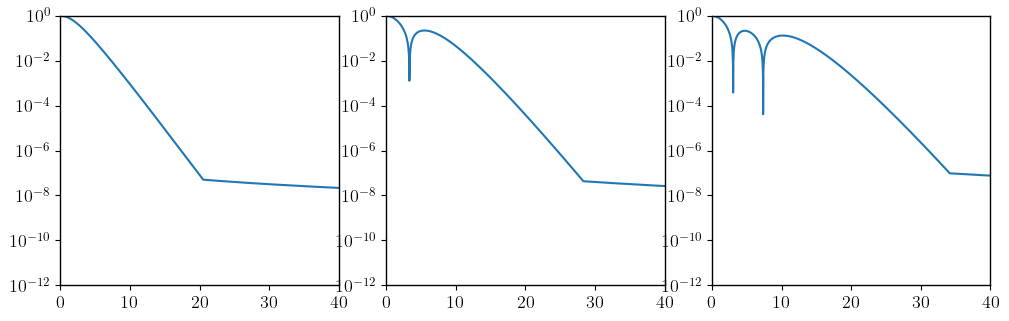

In [6]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(12, 3.5),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.1, wspace=.17) # espacio vertical y horizontal entre los subplots
                      )

ax[0].plot(rDnew1, sDnew1)
ax[1].plot(rDnew1n1, np.abs(sDnew1n1))
ax[2].plot(rDnew1n2, np.abs(sDnew1n2))

for i in ax:
   i.set_xlim(0, 40)
   i.set_yscale('log')
   i.set_ylim(1e-12, 1)

### Stability 

In [7]:
import Modules.SpectralMeth as sp
from scipy.interpolate import interp1d

In [8]:
# n = 0

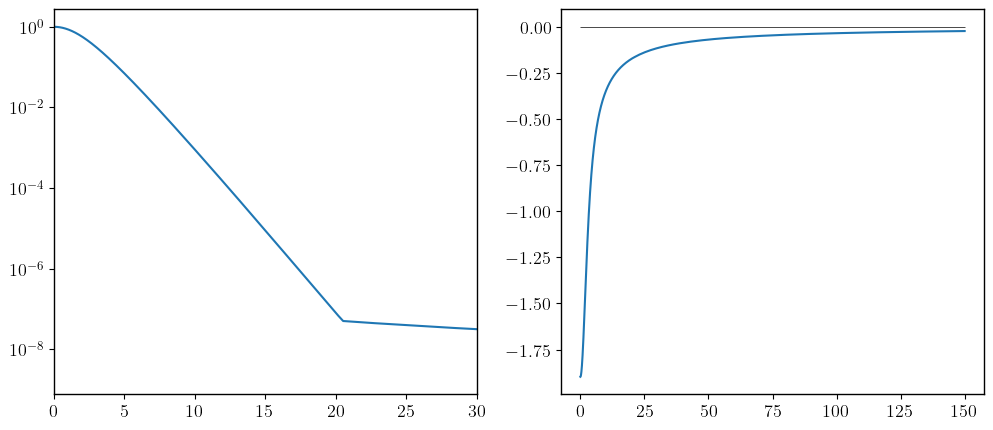

In [32]:
Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = s01

polariz = 'linear'
datFunc = [
    [interp1d(rDnew, sDnew)],
    [interp1d(rDnew, uDnew)],
]

nodos = 0
rMax = 200*(nodos+1) - 50
Nptos = int(3*rMax/4) * 2

Jval = [0, 1, 2, 3]
lamV = [0., 0.]
alp = 0.0

# Graphing
rad2 = np.linspace(0, rMax, 500000)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0, wspace=.2))

ax[0].plot(rad2, np.abs(datFunc[0][0](rad2)))
ax[1].plot(rad2, Ei - datFunc[1][0](rad2))
ax[1].hlines(0, 0, rMax, color='black', lw=0.5)
ax[0].set_xlim(0, 30)
ax[0].set_yscale('log')
plt.show()

lambdaVal, dataExtra = sp.LamJval(datFunc, rMax, lamV, alp, polariz, 
            Nptos=Nptos, Jval=Jval, info=False, fplot=False, real=False)

In [33]:
for ind, [Jval, data] in enumerate(dataExtra):
    rdis, eingVal, eigVect = data
    print('Jval = %d'%Jval)
    ind = np.abs(np.real(eingVal)) >= 1e-08 # filtrando los autovalores reales
    print(eingVal[ind])

Jval = 0
[]
Jval = 1
[]
Jval = 2
[]
Jval = 3
[]


Text(0, 0.5, '$\\lambda_I$')

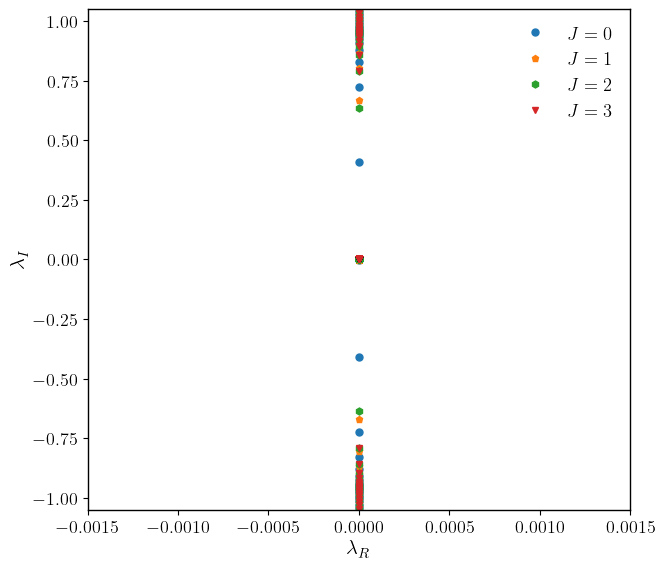

In [34]:
col = ['#1a1919', '#2681ab', '#0af5ce', '#05c9f5']
mark = ['o', 'p', 'h', 'v']

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7, 6.5),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.1, wspace=.17) # espacio vertical y horizontal entre los subplots
                      )
for ind, [Jval, data] in enumerate(dataExtra):
    _, eingVal, _ = data
    ax.plot(np.real(eingVal), np.imag(eingVal), ls='', marker=mark[ind], markersize=5, label=r'$J=%d$'%Jval)

#ax.text(x=-0.0014, y=0.9, s=r'zero nodes')
ax.legend(frameon=False, fontsize='small')
ax.set_xlim(-0.0015, 0.0015)
ax.set_ylim(-1.05, 1.05)

ax.set_xlabel(r'$\lambda_R$')  # \,[K^2/t_c]
ax.set_ylabel(r'$\lambda_I$')  # \,[K^2/t_c]

In [12]:
# n = 1

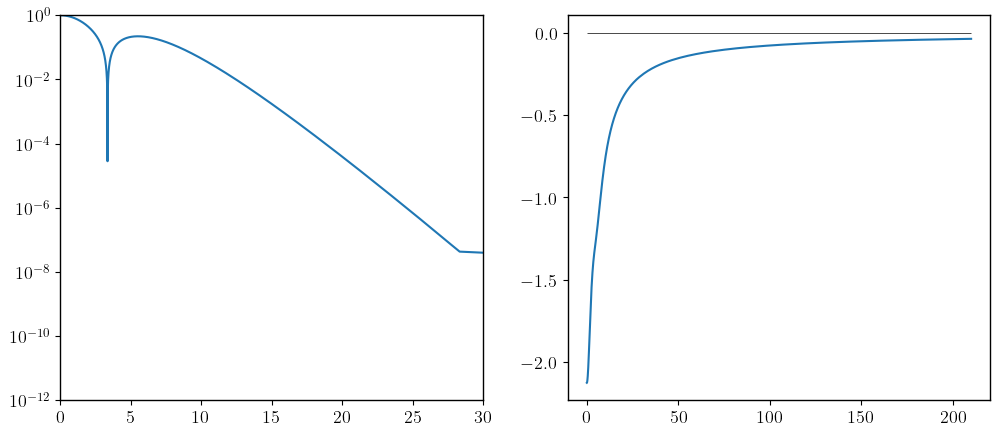

In [35]:
Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = s01n1

polariz = 'linear'
datFunc = [
    [interp1d(rDnew, sDnew)],
    [interp1d(rDnew, uDnew)],
]

nodos = 1
rMax = 210 #200*(nodos+1) - 10
Nptos = int(3*rMax/4) * 3

Jval = [0, 1, 2, 3]
lamV = [0., 0.]
alp = 0.0

# Graphing
rad2 = np.linspace(0, rMax, 500000)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0, wspace=.2))

ax[0].plot(rad2, np.abs(datFunc[0][0](rad2)))

ax[1].plot(rad2, Ei - datFunc[1][0](rad2))
ax[1].hlines(0, 0, rMax, color='black', lw=0.5)

ax[0].set_xlim(0, 30)
ax[0].set_yscale('log')
ax[0].set_ylim(1e-12, 1)

plt.show()


lambdaValn1, dataExtran1 = sp.LamJval(datFunc, rMax, lamV, alp, polariz, 
            Nptos=Nptos, Jval=Jval, info=False, fplot=False, real=False)

In [36]:
for ind, [Jval, data] in enumerate(dataExtran1):
    rdis, eingVal, eigVect = data
    print('Jval = %d'%Jval)
    ind = np.abs(np.real(eingVal)) >= 1e-08 # filtrando los autovalores reales
    print(eingVal[ind])

Jval = 0
[-0.0005148 -9.28417981e-13j  0.0005148 +6.41978659e-13j
  0.08827371-5.82904980e-01j -0.08827371-5.82904980e-01j
  0.08827371+5.82904980e-01j -0.08827371+5.82904980e-01j]
Jval = 1
[]
Jval = 2
[-0.09917583-6.66560244e-15j  0.09917583-6.87178629e-15j]
Jval = 3
[]


In [15]:
# Check with the prevous profile

In [16]:
test = np.load("stability/Polarization_constant/test_n1_linear.npy", allow_pickle=True)

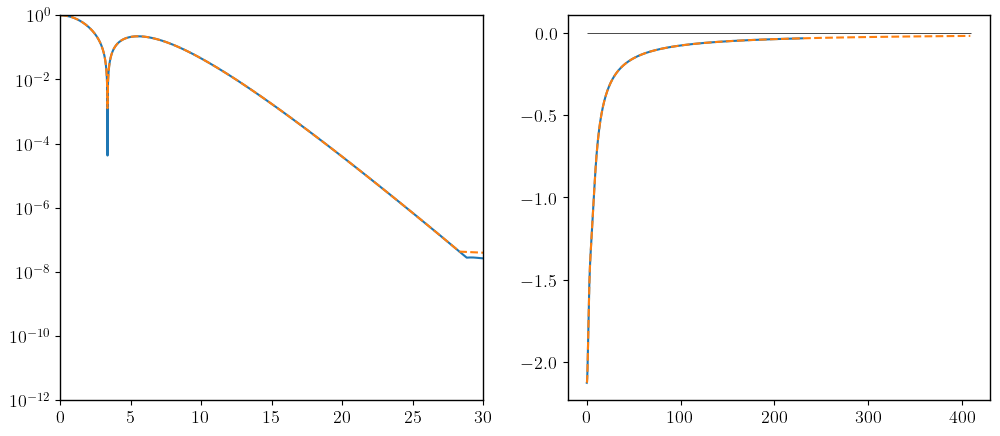

In [17]:
Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = s01n1

cte = test[0](0)/sDnew[0]

nodos = 1
rMax = 230 #200*(nodos+1) #- 50
Nptos = int(3*rMax/4) * 2

Jval = [0, 1, 2, 3]
lamV = [0., 0.]
alp = 0.0

# Escalando
rmaxE = rMax/np.sqrt(cte)
rmaxEdat= np.linspace(0, rmaxE, 500000)

polariz = 'linear'
datFunc = [
    [interp1d(rmaxEdat*np.sqrt(cte), test[0](rmaxEdat)/cte)],
    [interp1d(rmaxEdat*np.sqrt(cte), test[1](rmaxEdat)/cte)]
]

# Graphing
rad2 = np.linspace(0, rMax, 500000)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0, wspace=.2))

ax[0].plot(rad2, np.abs(datFunc[0][0](rad2)))
ax[0].plot(rDnew, np.abs(sDnew), ls='--')

ax[1].plot(rad2, Ei - datFunc[1][0](rad2))
ax[1].plot(rDnew, Ei - uDnew, ls='--')
ax[1].hlines(0, 0, 410, color='black', lw=0.5)

ax[0].set_xlim(0, 30)
ax[0].set_yscale('log')
ax[0].set_ylim(1e-12, 1)

plt.show()


lambdaValn1v2, dataExtran1v2 = sp.LamJval(datFunc, rMax, lamV, alp, polariz, 
            Nptos=Nptos, Jval=Jval, info=False, fplot=False)


In [18]:
for ind, [Jval, data] in enumerate(dataExtran1v2):
    rdis, eingVal, eigVect = data
    print('Jval = %d'%Jval)
    ind = np.abs(np.real(eingVal)) >= 1e-08 # filtrando los autovalores reales
    print(eingVal[ind])

Jval = 0
[ 0.0882742+0.58290394j -0.0882742+0.58290394j -0.0882742-0.58290394j
  0.0882742-0.58290394j]
Jval = 1
[]
Jval = 2
[ 0.09917674+2.78773980e-15j -0.09917674+3.13803161e-15j]
Jval = 3
[]


Jval = 0
[-0.0005148 -9.28417981e-13j  0.0005148 +6.41978659e-13j
  0.08827371-5.82904980e-01j -0.08827371-5.82904980e-01j
  0.08827371+5.82904980e-01j -0.08827371+5.82904980e-01j]
Jval = 1
[]
Jval = 2
[-0.09917583-6.66560244e-15j  0.09917583-6.87178629e-15j]
Jval = 3
[]


/var/folders/mf/vfyq6zyn4l35gfd2kgq4k2q00000gn/T/ipykernel_50139/3979307582.py:31: ComplexWarning: Casting complex values to real discards the imaginary part
  ax[0][0].text(x=20, y=-0.05, s=r'%5.5f'%eingVal[ind][0])
/var/folders/mf/vfyq6zyn4l35gfd2kgq4k2q00000gn/T/ipykernel_50139/3979307582.py:32: ComplexWarning: Casting complex values to real discards the imaginary part
  ax[1][0].text(x=20, y=-0.05, s=r'%5.5f'%eingVal[ind][1])


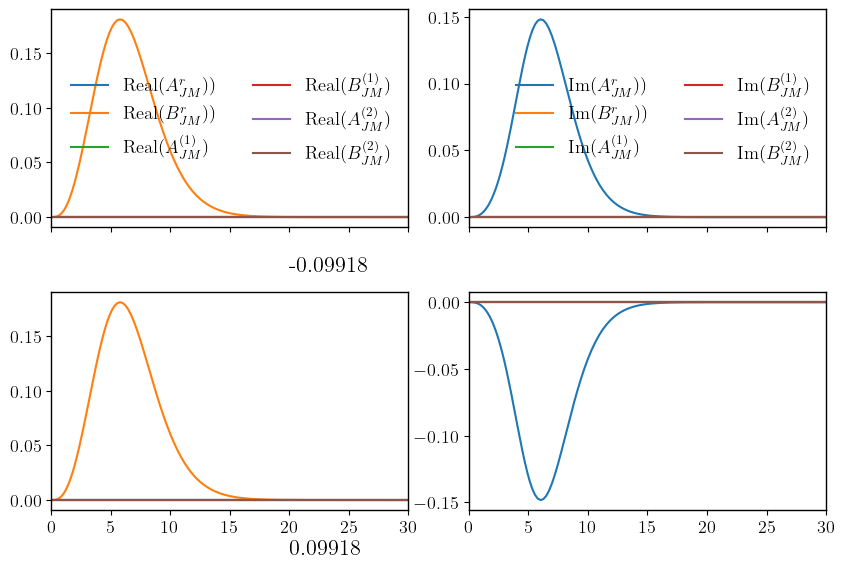

In [19]:
rMax = 210 #200*(nodos+1) - 10
Nptos = int(3*rMax/4) * 3

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 6.5),
                       sharex=True, sharey=False,
                       gridspec_kw=dict(hspace=0.3, wspace=.17) # espacio vertical y horizontal entre los subplots
                      )

# dataExtra.append([J, list([r_dis2, LambdaRealSorted, eig_vectors_sorted[:, jj]])])
for ind, [Jval, data] in enumerate(dataExtran1):
    rdis, eingVal, eigVect = data
    print('Jval = %d'%Jval)    
    ind = np.abs(np.real(eingVal)) >= 1e-06 # filtrando los autovalores reales
    print(eingVal[ind])
    
    if Jval==2:
        labels = ['$A_{JM}^{r}$)', '$B_{JM}^{r})$', '$A_{JM}^{(1)}$', '$B_{JM}^{(1)}$', '$A_{JM}^{(2)}$', '$B_{JM}^{(2)}$']
        datay = (eigVect[:, ind])[:, 0]
        for i in range(6):
            ax[0][0].plot(rdis, np.real(datay[i*(Nptos-1): (i+1)*(Nptos-1)]), label=r'Real(%s)'%labels[i])
            ax[0][1].plot(rdis, np.imag(datay[i*(Nptos-1): (i+1)*(Nptos-1)]), label=r'Im(%s)'%labels[i])
        
        ax[0][0].legend(frameon=False, fontsize='small', ncol=2)
        ax[0][1].legend(frameon=False, fontsize='small', ncol=2)
        
        datay = (eigVect[:, ind])[:, 1]
        for i in range(6):
            ax[1][0].plot(rdis, np.real(datay[i*(Nptos-1): (i+1)*(Nptos-1)]), label=r'Real(%s)'%labels[i])
            ax[1][1].plot(rdis, np.imag(datay[i*(Nptos-1): (i+1)*(Nptos-1)]), label=r'Im(%s)'%labels[i])
        
        ax[0][0].text(x=20, y=-0.05, s=r'%5.5f'%eingVal[ind][0])
        ax[1][0].text(x=20, y=-0.05, s=r'%5.5f'%eingVal[ind][1])
        ax[0][0].set_xlim(0, 30)
        ax[0][1].set_xlim(0, 30)

Text(0, 0.5, '$\\lambda_I$')

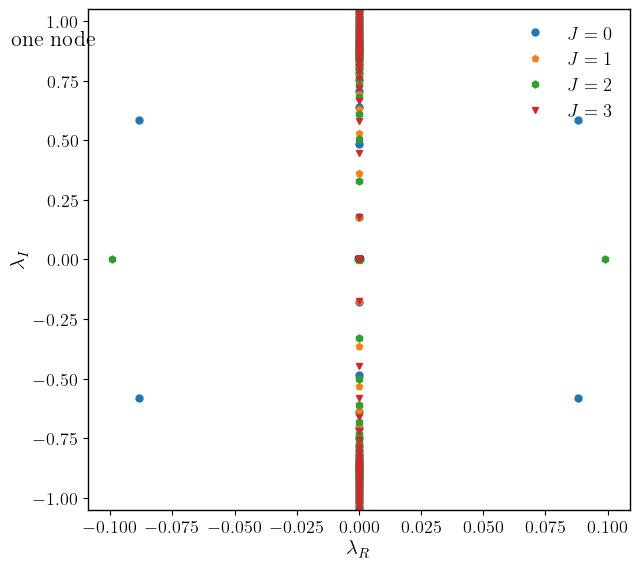

In [37]:
col = ['#1a1919', '#2681ab', '#0af5ce', '#05c9f5']
mark = ['o', 'p', 'h', 'v', '*']

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7, 6.5),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.1, wspace=.17) # espacio vertical y horizontal entre los subplots
                      )
for ind, [Jval, data] in enumerate(dataExtran1):
    _, eingVal, _ = data
    ax.plot(np.real(eingVal), np.imag(eingVal), ls='', marker=mark[ind], markersize=5, label=r'$J=%d$'%Jval)

ax.text(x=-0.14, y=0.9, s=r'one node')
ax.legend(frameon=False, fontsize='small')
#ax.set_xlim(-0.15, 0.15)
ax.set_ylim(-1.05, 1.05)

ax.set_xlabel(r'$\lambda_R$')  # \,[K^2/t_c]
ax.set_ylabel(r'$\lambda_I$')  # \,[K^2/t_c]

In [21]:
# Notar que desaparece el supuesto modo intestable de J=1 cuando cambias el rmax

In [22]:
# n = 2

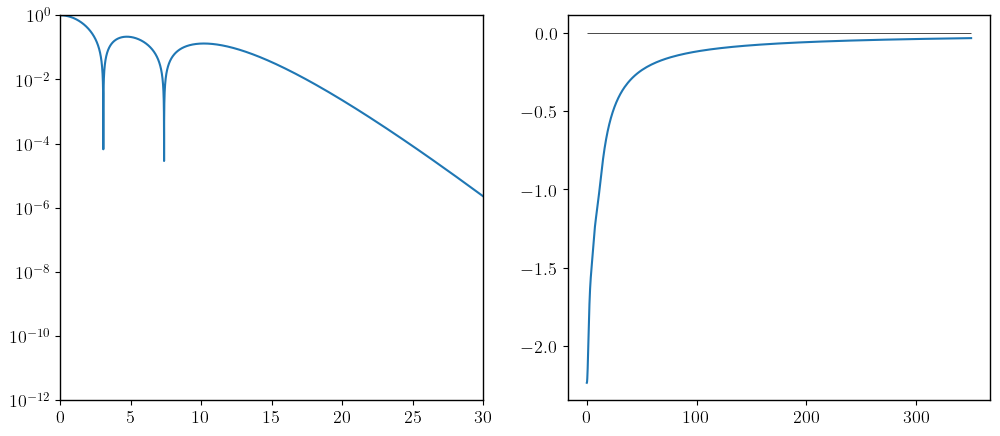

In [38]:
Ei, rDnew, sDnew, dsDnew, uDnew, duDnew = s01n2

polariz = 'linear'
datFunc = [
    [interp1d(rDnew, sDnew)],
    [interp1d(rDnew, uDnew)],
]

#Nptos, rMax = 700, 350.
nodos = 2
rMax = 350 #200*(nodos+1) - 50
Nptos = int(3*rMax/4) * 2

Jval = [0, 1, 2, 3]
lamV = [0, 0]
alp = 0

# Graphing
rad2 = np.linspace(0, rMax, 500000)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0, wspace=.2))

ax[0].plot(rad2, np.abs(datFunc[0][0](rad2)))

ax[1].plot(rad2, Ei - datFunc[1][0](rad2))
ax[1].hlines(0, 0, rMax, color='black', lw=0.5)

ax[0].set_xlim(0, 30)
ax[0].set_yscale('log')
ax[0].set_ylim(1e-12, 1)

plt.show()

lambdaValn2, dataExtran2 = sp.LamJval(datFunc, rMax, lamV, alp, polariz, 
            Nptos=Nptos, Jval=Jval, info=False, fplot=False, real=False)

In [39]:
for ind, [Jval, data] in enumerate(dataExtran2):
    _, eingVal, _ = data
    print('Jval = %d'%Jval)
    ind = np.abs(np.real(eingVal)) >= 1e-06
    print(eingVal[ind])

Jval = 0
[ 0.00033899-3.64175484e-12j -0.00033899+3.51322714e-12j
  0.07406735+3.21823440e-01j -0.07406735+3.21823440e-01j
  0.07406735-3.21823440e-01j -0.07406735-3.21823440e-01j
 -0.05402254-7.23121412e-01j  0.05402254-7.23121412e-01j
 -0.05402254+7.23121412e-01j  0.05402254+7.23121412e-01j]
Jval = 1
[ 0.00071237+2.19207557e-13j -0.00071237-2.25282630e-13j
 -0.01799502+3.87142965e-01j  0.01799502+3.87142965e-01j
  0.01799502-3.87142965e-01j -0.01799502-3.87142965e-01j]
Jval = 2
[ 0.08392238-9.14963388e-16j -0.08392238-7.92300217e-16j
  0.01074459-2.04213928e-01j -0.01074459-2.04213928e-01j
 -0.01074459+2.04213928e-01j  0.01074459+2.04213928e-01j]
Jval = 3
[]


Text(0, 0.5, '$\\lambda_I$')

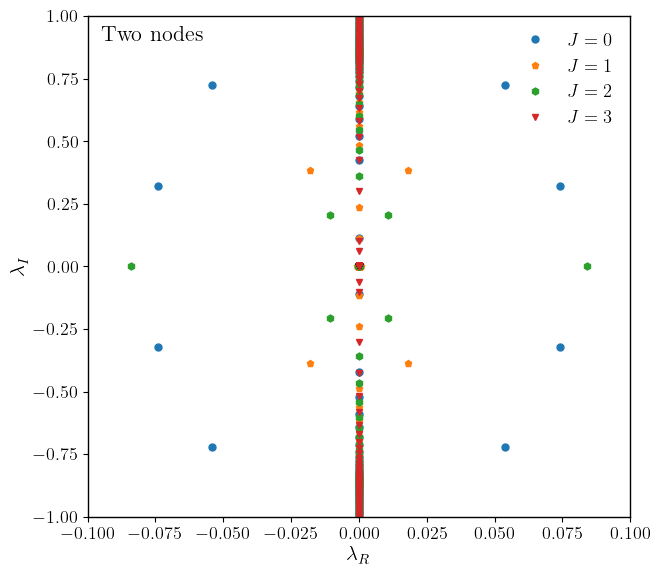

In [40]:
col = ['#1a1919', '#2681ab', '#0af5ce', '#05c9f5']
mark = ['o', 'p', 'h', 'v', '*']

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7, 6.5),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.1, wspace=.17) # espacio vertical y horizontal entre los subplots
                      )
for ind, [Jval, data] in enumerate(dataExtran2):
    _, eingVal, _ = data
    ax.plot(np.real(eingVal), np.imag(eingVal), ls='', marker=mark[ind], markersize=5, label=r'$J=%d$'%Jval)

ax.text(x=-0.095, y=0.9, s=r'Two nodes')
ax.legend(frameon=False, fontsize='small')
ax.set_xlim(-0.1, 0.1)
ax.set_ylim(-1., 1.)

ax.set_xlabel(r'$\lambda_R$')  # \,[K^2/t_c]
ax.set_ylabel(r'$\lambda_I$')  # \,[K^2/t_c]

In [41]:
# Data paper radial stability for ell=0 with 2 nodes and J=0
dat = np.array([0.00037420 + 0.00507753j, 0.00051995 + 0.00225911j])
datOb = np.array([0.00038088 + 2.79101031e-12j, -0.00038088 - 2.71422373e-12j, 
                  -0.07406746 - 3.21823430e-01j, 0.07406746 - 3.21823430e-01j,
                  -0.07406746 + 3.21823430e-01j, 0.07406746 + 3.21823430e-01j,
                  -0.05402295 + 7.23118035e-01j, 0.05402295 + 7.23118035e-01j,
                  -0.05402295 - 7.23118035e-01j, 0.05402295 - 7.23118035e-01j])
fac = np.real(dat[0])/np.real(datOb[-1])
datOb*fac

array([ 2.63823608e-06+1.93324514e-14j, -2.63823608e-06-1.88005749e-14j,
       -5.13042023e-04-2.22916978e-03j,  5.13042023e-04-2.22916978e-03j,
       -5.13042023e-04+2.22916978e-03j,  5.13042023e-04+2.22916978e-03j,
       -3.74200000e-04+5.00881142e-03j,  3.74200000e-04+5.00881142e-03j,
       -3.74200000e-04-5.00881142e-03j,  3.74200000e-04-5.00881142e-03j])

In [42]:
# Plotting

Text(0.014, -0.98, 'stationary (constant)')

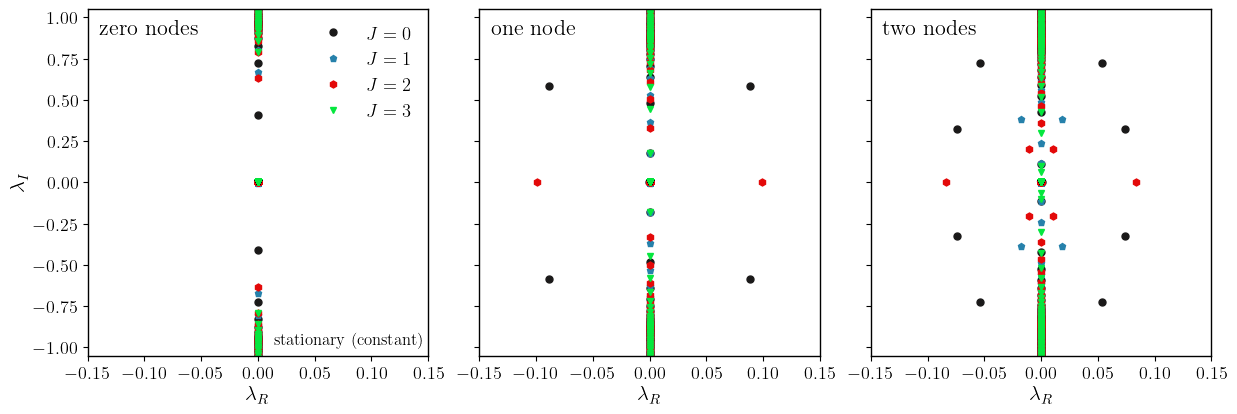

In [43]:
#col = ['#1a1919', '#2681ab', '#0af5ce', '#05c9f5']
col = ['#1a1919', '#2681ab', "#e30909", "#05e73e"]
mark = ['o', 'p', 'h', 'v']

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(14.5, 4.5),
                       sharex=False, sharey=True,
                       gridspec_kw=dict(hspace=0, wspace=.15) # espacio vertical y horizontal entre los subplots
                      )

for ind, [Jval, data] in enumerate(dataExtra):
    _, eingVal, _ = data
    ax[0].plot(np.real(eingVal), np.imag(eingVal), ls='', marker=mark[ind], c=col[ind], markersize=5, label=r'$J=%d$'%Jval)

for ind, [Jval, data] in enumerate(dataExtran1):
    _, eingVal, _ = data
    ax[1].plot(np.real(eingVal), np.imag(eingVal), ls='', marker=mark[ind], c=col[ind], markersize=5, label=r'$J=%d$'%Jval)

for ind, [Jval, data] in enumerate(dataExtran2):
    _, eingVal, _ = data
    ax[2].plot(np.real(eingVal), np.imag(eingVal), ls='', marker=mark[ind], c=col[ind], markersize=5, label=r'$J=%d$'%Jval)
    
#ax.text(x=-0.14, y=0.9, s=r'one node')
ax[0].legend(frameon=False, fontsize='small')

nodes = [r'zero nodes', r'one node', r'two nodes']
for i in range(3):
    ax[i].set_xlim(-0.15, 0.15)
    ax[i].text(x=-0.14, y=0.9, s=nodes[i])
    ax[i].set_xlabel(r'$\lambda_R$')  # \,[K^2/t_c]
ax[0].set_ylim(-1.05, 1.05)
ax[0].set_ylabel(r'$\lambda_I$')  # \,[K^2/t_c]

ax[0].text(x=0.014, y=-0.98, s=r'stationary (constant)', fontsize='12')

In [44]:
fig.savefig('stationary_cte.pdf', format='pdf', #metadata=None, # dpi='figure',
        pad_inches=0.1,
        facecolor='auto', edgecolor='auto',
        backend=None, dpi=1000, 
        bbox_inches='tight'# Plot will be occupy a maximum of available space # bbox_inches=None,
       )